# PLL for Market Microstructure – Adaptive Price Denoising

This notebook demonstrates the adaptive Kalman filter that mimics a Phase‑Locked Loop (PLL).
The measurement noise is scaled by the bid‑ask spread, exactly like a PLL adjusts its bandwidth based on SNR.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
from data_loader import load_tick_data
from kalman_pll import AdaptiveKalmanPLL
import visualization as viz

## 1. Load Data

Replace `'../data/your_data.csv'` with the actual path to your CSV file.
The file must have columns: `timestamp`, `bid_price`, `ask_price`.

In [2]:
df = load_tick_data('../data/sample_ticks.csv')
df.head()

,timestamp,bid_price,ask_price,mid_price,spread
0,2025-01-01 09:30:00.000,149.992,150.009,150.0005,0.017
1,2025-01-01 09:30:00.250,149.709,150.113,149.9110,0.404
2,2025-01-01 09:30:00.500,150.021,150.056,150.0385,0.035
3,2025-01-01 09:30:00.750,150.094,150.133,150.1135,0.039
4,2025-01-01 09:30:01.000,150.088,150.099,150.0935,0.011


## 2. Run Filter

Parameters:
- `process_noise` (Q) – variance of state transition. Typically small.
- `alpha` – scales the spread to measurement noise. Tune to get smooth result.

In [3]:
pll = AdaptiveKalmanPLL(process_noise=0.001, alpha=0.5)
pll.initialize(initial_price=df['mid_price'].iloc[0], initial_covariance=1.0)

filtered = []
for idx, row in df.iterrows():
    pll.predict()
    filtered_price = pll.update(row['mid_price'], row['spread'])
    filtered.append(filtered_price)

## 3. Visualize

Plot the observed mid‑price, the filtered price, the spread, and the measurement noise variance.

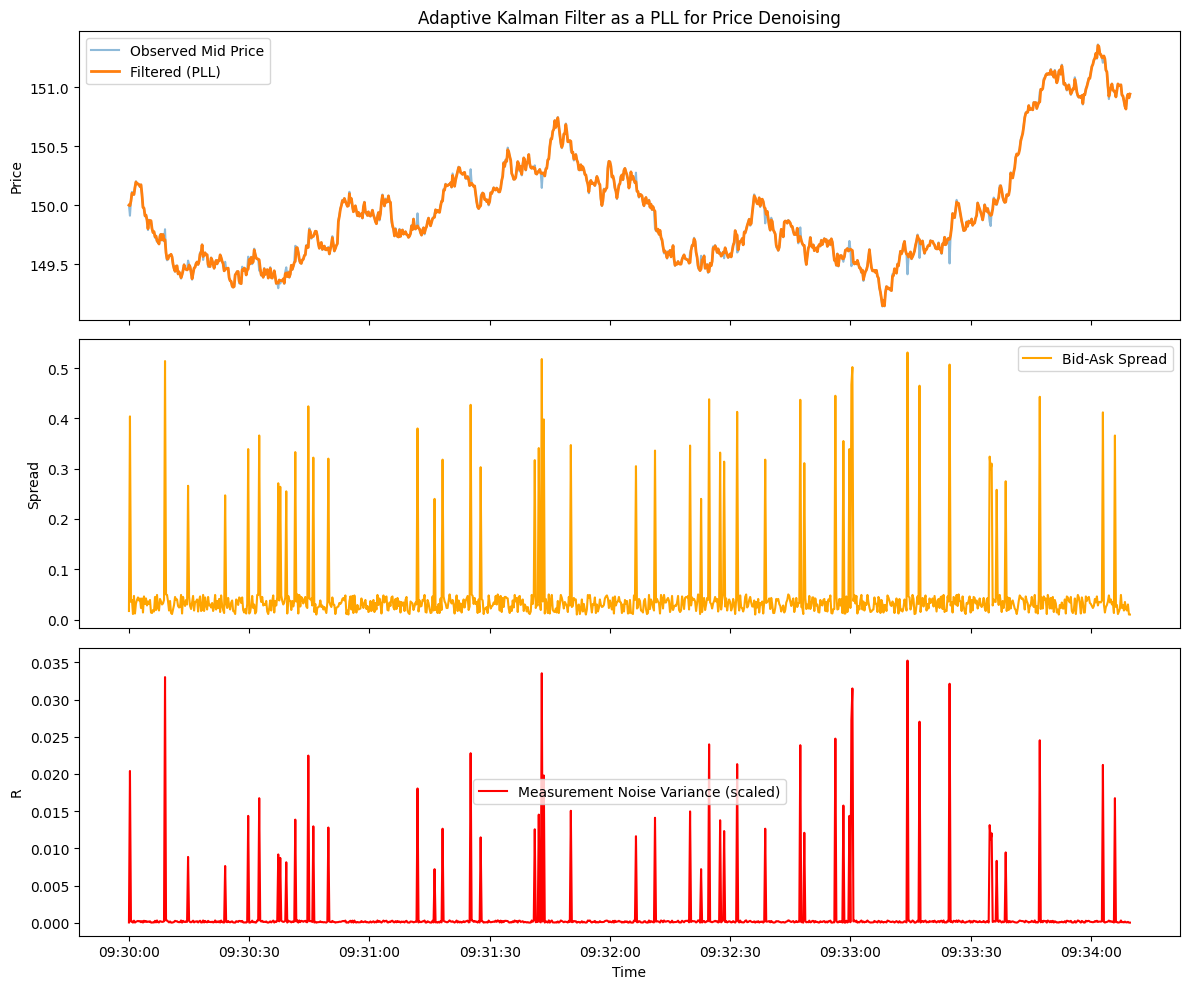

In [4]:
viz.plot_results(df, filtered, spread_scaled_noise=((df['spread']/2)**2 * 0.5))

## 4. Compare with Simple Moving Average

We can add a simple EMA to show the advantage of adaptive filtering.

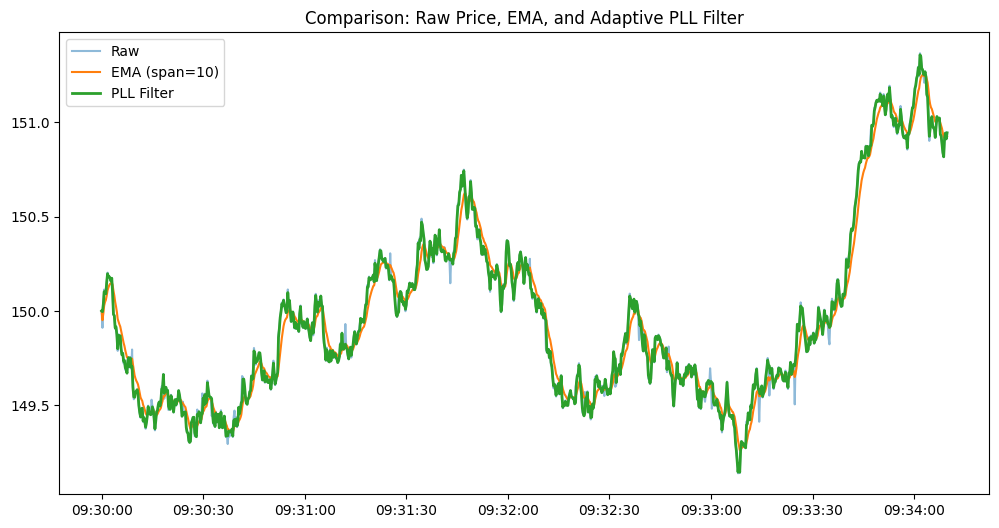

In [5]:
import matplotlib.pyplot as plt

ema = df['mid_price'].ewm(span=10).mean()

plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['mid_price'], alpha=0.5, label='Raw')
plt.plot(df['timestamp'], ema, label='EMA (span=10)')
plt.plot(df['timestamp'], filtered, label='PLL Filter', linewidth=2)
plt.legend()
plt.title('Comparison: Raw Price, EMA, and Adaptive PLL Filter')
plt.show()